# 0. Segmentation map으로 도로 이미지 만들기

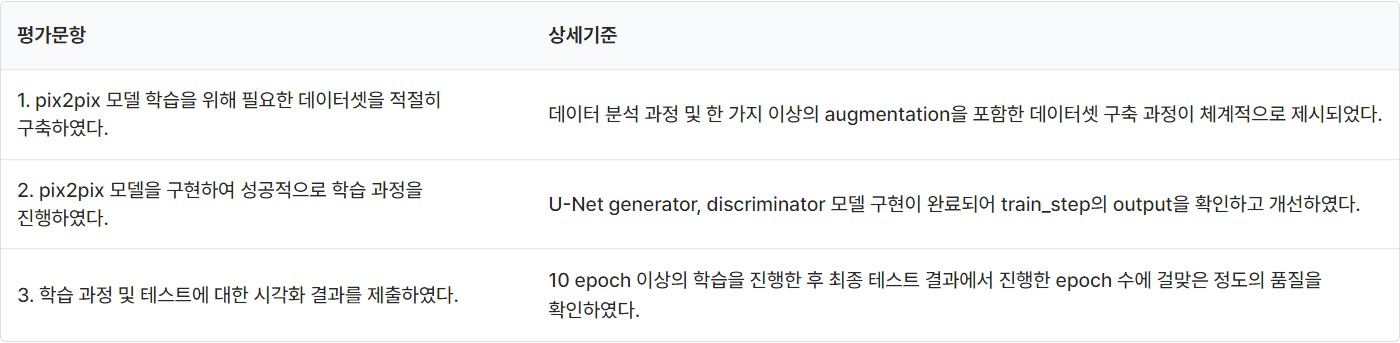

In [43]:
import os

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import random_rotation
from tensorflow.keras import layers, Input, Model
from tensorflow.keras import losses
from tensorflow.keras import optimizers

1. 데이터에 한 가지 이상의 augmentation 방법을 적용하여 학습해 주세요.  
(어떠한 방법을 사용했는지 적어주세요.)  
2. 이전에 구현했던 두 개의 Generator 중 Encoder와 Decoder간에 skip connection이 있는 U-Net Generator를 사용해 주세요.  
3. 모델 학습 후, 학습된 Generator를 이용해 테스트합니다. 테스트 데이터는 다운로드했던 "val" 폴더 내 이미지를 사용해 주세요.  
4. 1개 이상의 이미지에 대해 테스트 과정을 거친 후 그 결과를 스케치, 생성된 사진, 실제 사진 순서로 나란히 시각화해 주세요.  
5. 모델을 충분히 학습하기에 시간이 부족할 수 있습니다. 적어도 10 epoch 이상 학습하며 중간 손실 값에 대한 로그를 남겨주세요. 좋은 결과를 얻기 위해선 긴 학습 시간이 필요하므로 테스트 결과는 만족스럽지 않아도 괜찮습니다.

In [44]:
data_path = os.getenv('HOME') + '/aiffel/conditional_generation/data/cityscapes/train/'
val_data_path = os.getenv('HOME') + '/aiffel/conditional_generation/data/cityscapes/val/'
print("number of train examples :", len(os.listdir(data_path)))
print("number of train examples :", len(os.listdir(val_data_path)))

number of train examples : 1000
number of train examples : 5


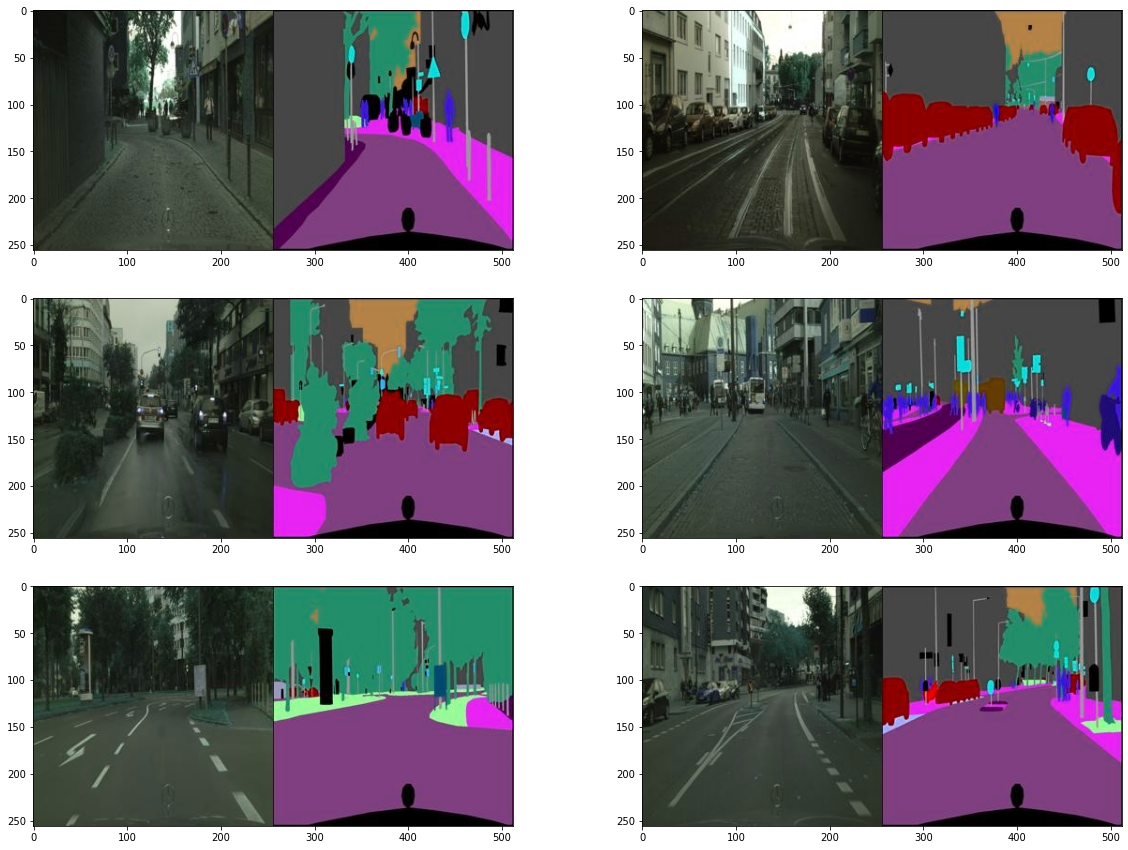

In [45]:
plt.figure(figsize=(20, 15))

for i in range(1, 7):
    f = data_path + os.listdir(data_path)[np.random.randint(1000)]
    img = cv2.imread(f, cv2.IMREAD_COLOR)
    plt.subplot(3, 2, i)
    plt.imshow(img)

In [46]:
f = data_path + os.listdir(data_path)[0]
img = cv2.imread(f, cv2.IMREAD_COLOR)
print(img.shape)

(256, 512, 3)


In [47]:
def normalize(x):
    x = tf.cast(x, tf.float32)
    return (x / 127.5) - 1

def denormalize(x):
    x = (x + 1) * 127.5
    x = x.numpy()
    return x.astype(np.uint8)

def load_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, 3)
    
    w = tf.shape(img)[1] // 2
    segment = img[: , w: , : ] 
    segment = tf.cast(segment, tf.float32)
    truth = img[: , : w, : ] 
    truth = tf.cast(truth, tf.float32)
    return normalize(segment), normalize(truth)

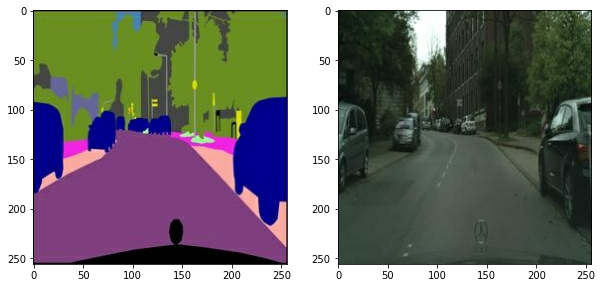

In [48]:
f = data_path + os.listdir(data_path)[0]
sketch, colored = load_img(f)

plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(sketch))
plt.subplot(1, 2, 2)
plt.imshow(denormalize(colored))

In [49]:
@tf.function() # 빠른 텐서플로 연산을 위해 @tf.function()을 사용합니다. 
def apply_augmentation(sketch, colored):
    stacked = tf.concat([sketch, colored], axis=-1)
    
    _pad = tf.constant([[30, 30], [30, 30], [0, 0]])
    if tf.random.uniform(()) < 0.5:
        padded = tf.pad(stacked, _pad, "REFLECT")
    else:
        padded = tf.pad(stacked, _pad, "CONSTANT", constant_values=1.)

    out = tf.image.random_crop(padded, size=[256, 256, 6])
    
    out = tf.image.random_flip_left_right(out)
    out = tf.image.random_flip_up_down(out)
    
    if tf.random.uniform(()) < 0.5:
        degree = tf.random.uniform([], minval=1, maxval=4, dtype=tf.int32)
        out = tf.image.rot90(out, k=degree)
    
    return out[..., : 3], out[..., 3: ]

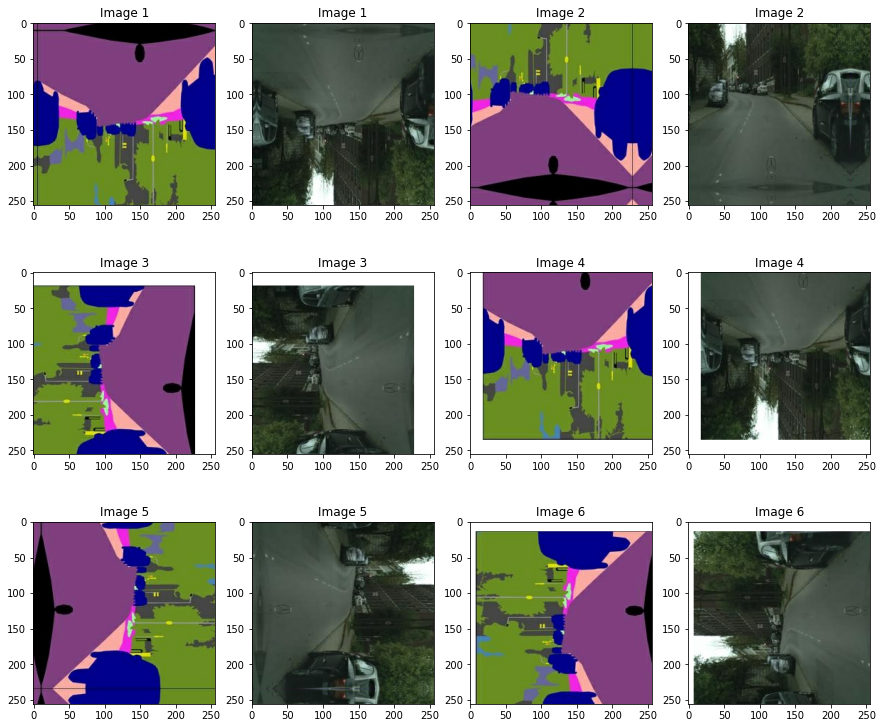

In [50]:
plt.figure(figsize=(15, 13))
img_n = 1
for i in range(1, 13, 2):
    augmented_sketch, augmented_colored = apply_augmentation(sketch, colored)
    
    plt.subplot(3, 4, i)
    plt.imshow(denormalize(augmented_sketch))
    plt.title(f"Image {img_n}")
    plt.subplot(3, 4, i+1)
    plt.imshow(denormalize(augmented_colored))
    plt.title(f"Image {img_n}")
    img_n += 1

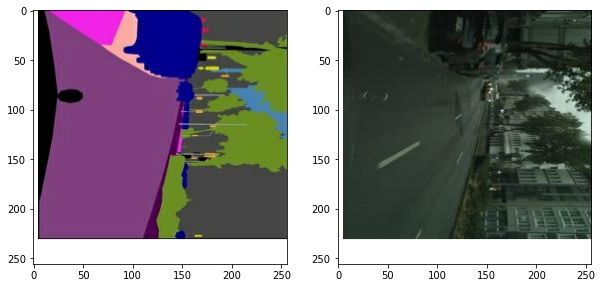

In [51]:
def get_train(img_path):
    sketch, colored = load_img(img_path)
    sketch, colored = apply_augmentation(sketch, colored)
    return sketch, colored

train_images = tf.data.Dataset.list_files(data_path + "*.jpg")
train_images = train_images.map(get_train).shuffle(1000).batch(8)

sample = train_images.take(1)
sample = list(sample.as_numpy_iterator())
sketch, colored = (sample[0][0] + 1) * 127.5, (sample[0][1] + 1) * 127.5

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sketch[0].astype(np.uint8))
plt.subplot(1, 2, 2)
plt.imshow(colored[0].astype(np.uint8))

In [52]:
class EncodeBlock(layers.Layer):
    def __init__(self, n_filters, use_bn=True):
        super(EncodeBlock, self).__init__()
        self.use_bn = use_bn       
        self.conv = layers.Conv2D(n_filters, 4, 2, "same", use_bias=False)
        self.batchnorm = layers.BatchNormalization()
        self.lrelu = layers.LeakyReLU(0.2)

    def call(self, x):
        x = self.conv(x)
        if self.use_bn:
            x = self.batchnorm(x)
        return self.lrelu(x)
    
class DecodeBlock(layers.Layer):
    def __init__(self, f, dropout=True):
        super(DecodeBlock, self).__init__()
        self.dropout = dropout
        self.Transconv = layers.Conv2DTranspose(f, 4, 2, "same", use_bias=False)
        self.batchnorm = layers.BatchNormalization()
        self.relu = layers.ReLU()
        
    def call(self, x):
        x = self.Transconv(x)
        x = self.batchnorm(x)
        if self.dropout:
            x = layers.Dropout(0.5)(x)
        return self.relu(x)
    

In [53]:
class UNetGenerator(Model):
    def __init__(self):
        super(UNetGenerator, self).__init__()
        encode_filters = [64, 128, 128, 256, 256, 512, 512, 1024]
        decode_filters = [512, 512, 256, 256, 128, 128, 64]
        
        self.encode_blocks = []
        for i, f in enumerate(encode_filters):
            if i == 0:
                self.encode_blocks.append(EncodeBlock(f, use_bn=False))
            else:
                self.encode_blocks.append(EncodeBlock(f))
        
        self.decode_blocks = []
        for i, f in enumerate(decode_filters):
            if i < 3:
                self.decode_blocks.append(DecodeBlock(f))
            else:
                self.decode_blocks.append(DecodeBlock(f, dropout=False))
        
        self.last_conv = layers.Conv2DTranspose(3, 4, 2, "same", use_bias=False)
    
    def call(self, x):
        features = []
        for block in self.encode_blocks:
            x = block(x)
            features.append(x)
        
        features = features[: -1]
                    
        for block, feat in zip(self.decode_blocks, features[: :-1]):
            x = block(x)
            x = layers.Concatenate()([x, feat])
        
        x = self.last_conv(x)
        return x
                
    def get_summary(self, input_shape=(256, 256, 3)):
        inputs = Input(input_shape)
        return Model(inputs, self.call(inputs)).summary()

In [54]:
UNetGenerator().get_summary()

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
encode_block_32 (EncodeBlock)   (None, 128, 128, 64) 3072        input_7[0][0]                    
__________________________________________________________________________________________________
encode_block_33 (EncodeBlock)   (None, 64, 64, 128)  131584      encode_block_32[0][0]            
__________________________________________________________________________________________________
encode_block_34 (EncodeBlock)   (None, 32, 32, 128)  262656      encode_block_33[0][0]            
____________________________________________________________________________________________

In [55]:
class DiscBlock(layers.Layer):
    def __init__(self, n_filters, stride=2, custom_pad=False, use_bn=True, act=True):
        super(DiscBlock, self).__init__()
        self.custom_pad = custom_pad
        self.use_bn = use_bn
        self.act = act
        
        if custom_pad:
            self.padding = layers.ZeroPadding2D()
            self.conv = layers.Conv2D(n_filters, 4, stride, "valid", use_bias=False)
        else:
            self.conv = layers.Conv2D(n_filters, 4, stride, "same", use_bias=False)
        
        self.batchnorm = layers.BatchNormalization() if use_bn else None
        self.lrelu = layers.LeakyReLU(0.2) if act else None
        
    def call(self, x):
        if self.custom_pad:
            x = self.padding(x)
            x = self.conv(x)
        else:
            x = self.conv(x)
                
        if self.use_bn:
            x = self.batchnorm(x)
            
        if self.act:
            x = self.lrelu(x)
        return x 

In [56]:
class Discriminator(Model):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.block0 = layers.Concatenate()
        self.block1 = DiscBlock(n_filters=64, stride=2, custom_pad=False, use_bn=False, act=True)
        self.block2 = DiscBlock(n_filters=64, stride=1, custom_pad=True, use_bn=True, act=True)        
        self.block3 = DiscBlock(n_filters=128, stride=2, custom_pad=False, use_bn=True, act=True)
        self.block4 = DiscBlock(n_filters=128, stride=1, custom_pad=True, use_bn=True, act=True)
        self.block5 = DiscBlock(n_filters=256, stride=2, custom_pad=False, use_bn=True, act=True)
        self.block6 = DiscBlock(n_filters=256, stride=1, custom_pad=True, use_bn=True, act=True)
        self.block7 = DiscBlock(n_filters=512, stride=2, custom_pad=False, use_bn=True, act=True)
        self.block8 = DiscBlock(n_filters=1, stride=1, custom_pad=True, use_bn=False, act=False)
        self.sigmoid = layers.Activation("sigmoid")
        
        # filters = [64,128,256,512,1]
        # self.blocks = [layers.Concatenate()]
        # for i, f in enumerate(filters):
        #     self.blocks.append(DiscBlock(
        #         n_filters=f,
        #         strides=2 if i<3 else 1,
        #         custom_pad=False if i<3 else True,
        #         use_bn=False if i==0 and i==4 else True,
        #         act=True if i<4 else False
        #     ))
    
    def call(self, x, y):
        out = self.block0([x, y])
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.block5(out)
        out = self.block6(out)
        out = self.block7(out)
        out = self.block8(out)
        return self.sigmoid(out)
    
    def get_summary(self, x_shape=(256, 256, 3), y_shape=(256, 256, 3)):
        x, y = Input(x_shape), Input(y_shape) 
        return Model((x, y), self.call(x, y)).summary()
    

In [57]:
Discriminator().get_summary()

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_8 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
input_9 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
concatenate_41 (Concatenate)    (None, 256, 256, 6)  0           input_8[0][0]                    
                                                                 input_9[0][0]                    
__________________________________________________________________________________________________
disc_block_48 (DiscBlock)       (None, 128, 128, 64) 6144        concatenate_41[0][0]       

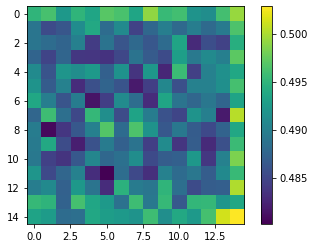

In [58]:
x = tf.random.normal([1, 256, 256, 3])
y = tf.random.uniform([1, 256, 256, 3])

disc_out = Discriminator()(x, y)
plt.imshow(disc_out[0, ... , 0])
plt.colorbar()

In [59]:
bce = losses.BinaryCrossentropy(from_logits=False)
mae = losses.MeanAbsoluteError()

def get_gene_loss(fake_output, real_output, fake_disc):
    l1_loss = mae(real_output, fake_output)
    gene_loss = bce(tf.ones_like(fake_disc), fake_disc)
    return gene_loss, l1_loss

def get_disc_loss(fake_disc, real_disc):
    return bce(tf.zeros_like(fake_disc), fake_disc) + bce(tf.ones_like(real_disc), real_disc)

In [60]:
gene_opt = optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = optimizers.Adam(2e-4, beta_1=0.5)

In [61]:
@tf.function
def train_step(sketch, real_colored):
    with tf.GradientTape() as gene_tape, tf.GradientTape() as disc_tape:
        # Generator 예측
        fake_colored = generator(sketch, training=True)
        # Discriminator 예측
        fake_disc = discriminator(sketch, fake_colored, training=True)
        real_disc = discriminator(sketch, real_colored, training=True)
        # Generator 손실 계산
        gene_loss, l1_loss = get_gene_loss(fake_colored, real_colored, fake_disc)
        gene_total_loss = gene_loss + (2 ** 7 * l1_loss) ## <===== L1 손실 반영 λ=100
        # Discrminator 손실 계산
        disc_loss = get_disc_loss(fake_disc, real_disc)
                
    gene_gradient = gene_tape.gradient(gene_total_loss, generator.trainable_variables)
    disc_gradient = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    gene_opt.apply_gradients(zip(gene_gradient, generator.trainable_variables))
    disc_opt.apply_gradients(zip(disc_gradient, discriminator.trainable_variables))
    return gene_loss, l1_loss, disc_loss

In [ ]:
EPOCHS = 2 ** 6

generator = UNetGenerator()
discriminator = Discriminator()

for epoch in range(1, EPOCHS+1):
    for i, (sketch, colored) in enumerate(train_images):
        g_loss, l1_loss, d_loss = train_step(sketch, colored)
                
        # 10회 반복마다 손실을 출력합니다.
        if (i+1) % 10 == 0:
            print(f"EPOCH[{epoch}] - STEP[{i+1}] \
                    \nGenerator_loss:{g_loss.numpy():.4f} \
                    \nL1_loss:{l1_loss.numpy():.4f} \
                    \nDiscriminator_loss:{d_loss.numpy():.4f}", end="\n\n")

EPOCH[1] - STEP[10]                     
Generator_loss:1.0683                     
L1_loss:0.3860                     
Discriminator_loss:1.1524

EPOCH[1] - STEP[20]                     
Generator_loss:1.2417                     
L1_loss:0.2350                     
Discriminator_loss:2.2310

EPOCH[1] - STEP[30]                     
Generator_loss:0.4194                     
L1_loss:0.2147                     
Discriminator_loss:1.7583

EPOCH[1] - STEP[40]                     
Generator_loss:1.1613                     
L1_loss:0.1996                     
Discriminator_loss:0.8772

EPOCH[1] - STEP[50]                     
Generator_loss:1.5832                     
L1_loss:0.1749                     
Discriminator_loss:1.0739

EPOCH[1] - STEP[60]                     
Generator_loss:0.7060                     
L1_loss:0.1870                     
Discriminator_loss:1.0775

EPOCH[1] - STEP[70]                     
Generator_loss:1.9810                     
L1_loss:0.2246                    

In [ ]:
test_ind = 0

f = data_path + os.listdir(data_path)[test_ind]
sketch, colored = load_img(f)

pred = generator(tf.expand_dims(sketch, 0))
pred = denormalize(pred)

plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(denormalize(sketch))
plt.subplot(1, 3, 2)
plt.imshow(pred[0])
plt.subplot(1, 3, 3)
plt.imshow(denormalize(colored))